<a href="https://colab.research.google.com/github/DrishtiNigam1928/CUSTOMER_CHURN/blob/main/notebooks/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving E Commerce Dataset.xlsx to E Commerce Dataset (3).xlsx


In [ ]:
import os
print(os.listdir())

['.config', 'E Commerce Dataset (1).xlsx', 'E Commerce Dataset (3).xlsx', 'E Commerce Dataset.xlsx', 'E Commerce Dataset (2).xlsx', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

FILENAME = "E Commerce Dataset.xlsx"   # match this exactly to what os.listdir() showed
df = pd.read_excel(FILENAME, sheet_name="E Comm")

print("Shape:", df.shape)
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:

num_rows = 0
for _ in df.itertuples():
    num_rows += 1
print("Number of rows/observations:", num_rows)

# 2. Number of columns/features (without .shape)
column_list = []
for col in df:
    column_list.append(col)
num_cols = len(column_list)
print("Number of columns/features:", num_cols)
print("Column names:", column_list)

Number of rows/observations: 5630
Number of columns/features: 20
Column names: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [ ]:
#A2: Input features & Target variable
target_col = "Churn"
id_col = "CustomerID"

input_features = [c for c in df.columns if c not in [target_col, id_col]]

print("Target variable:", target_col)
print("Number of input features:", len(input_features))
print("Input features:", input_features)

Target variable: Churn
Number of input features: 18
Input features: ['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [ ]:
#  A2: Numerical vs Categorical variables -
numerical_vars = df[input_features].select_dtypes(include=np.number).columns.tolist()
categorical_vars = df[input_features].select_dtypes(exclude=np.number).columns.tolist()

print("Numerical variables (", len(numerical_vars), "):", numerical_vars)
print()
print("Categorical variables (", len(categorical_vars), "):", categorical_vars)


Numerical variables ( 13 ): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical variables ( 5 ): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [ ]:
# A2: Source of dataset -
print("Source: Kaggle - Ecommerce Customer Churn Analysis and Prediction")
print("URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

Source: Kaggle - Ecommerce Customer Churn Analysis and Prediction
URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction


In [ ]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
def execute_task_B1(dataframe):
  print("Task B1: Initial Data Exploration and Structure Inspection\n")

  display(df.head(3))
  print("\n")
  display(df.tail(3))
  print("\n")
  rows, cols = dataframe.shape
  print(f"Total Number of Rows: {rows}\n")
  print(f"Total Number of Columns: {cols}\n")

  print(f"{'Column Name':<35} | {'Data Type':<15} | {'Unique Values':<15} | {'Missing Values'}")
  for col in dataframe.columns:
    col_name=col
    dtype=str(dataframe[col].dtype)
    unique_vals = dataframe[col].nunique()
    missing_vals = dataframe[col].isnull().sum()
    print(f"{col_name:<35} | {dtype:<15} | {unique_vals:<15} | {missing_vals}")

execute_task_B1(df)
print("\nTask B1 Completed Successfully!")


Task B1: Initial Data Exploration and Structure Inspection



,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169.04




Total Number of Rows: 5630

Total Number of Columns: 20

Column Name                         | Data Type       | Unique Values   | Missing Values
CustomerID                          | int64           | 5630            | 0
Churn                               | int64           | 2               | 0
Tenure                              | float64         | 36              | 264
PreferredLoginDevice                | object          | 3               | 0
CityTier                            | int64           | 3               | 0
WarehouseToHome                     | float64         | 34              | 251
PreferredPaymentMode                | object          | 7               | 0
Gender                              | object          | 2               | 0
HourSpendOnApp                      | float64         | 6               | 255
NumberOfDeviceRegistered            | int64           | 6               | 0
PreferedOrderCat                    | object          | 6               | 0
Satisfacti

In [ ]:

# B2
def calc_mean(values):
    return sum(values) / len(values)

def calc_min(values):
    m = values[0]
    for v in values:
        if v < m:
            m = v
    return m

def calc_max(values):
    m = values[0]
    for v in values:
        if v > m:
            m = v
    return m

def calc_median(values):
    sorted_vals = sorted(values)
    n = len(sorted_vals)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_vals[mid - 1] + sorted_vals[mid]) / 2
    else:
        return sorted_vals[mid]

def calc_mode(values):
    freq = {}
    for v in values:
        freq[v] = freq.get(v, 0) + 1
    max_count = max(freq.values())
    for v, c in freq.items():
        if c == max_count:
            return v

def calc_variance(values, mean_val):
    squared_diffs = [(v - mean_val) ** 2 for v in values]
    return sum(squared_diffs) / len(values)   # population variance, matches the formula given

def calc_std(variance_val):
    return variance_val ** 0.5

def calc_range(min_val, max_val):
    return max_val - min_val

In [ ]:

stats_dict = {}

for col in numerical_vars:
    values = [v for v in df[col] if pd.notna(v)]

    col_mean = calc_mean(values)
    col_min = calc_min(values)
    col_max = calc_max(values)
    col_median = calc_median(values)
    col_mode = calc_mode(values)
    col_variance = calc_variance(values, col_mean)
    col_std = calc_std(col_variance)
    col_range = calc_range(col_min, col_max)

    stats_dict[col] = {
        "Mean": col_mean, "Median": col_median, "Mode": col_mode,
        "Min": col_min, "Max": col_max, "Range": col_range,
        "Variance": col_variance, "Std Dev": col_std
    }

stats_table = pd.DataFrame(stats_dict).T
stats_table

,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev
Tenure,10.189899,9.00,1.00,0.0,61.00,61.00,73.212727,8.556444
CityTier,1.654707,1.00,1.00,1.0,3.00,2.00,0.837789,0.915308
WarehouseToHome,15.639896,14.00,9.00,5.0,127.00,122.00,72.772537,8.530682
HourSpendOnApp,2.931535,3.00,3.00,0.0,5.00,5.00,0.521080,0.721859
NumberOfDeviceRegistered,3.688988,4.00,4.00,1.0,6.00,5.00,1.048387,1.023908
SatisfactionScore,3.066785,3.00,3.00,1.0,5.00,4.00,1.904598,1.380072
NumberOfAddress,4.214032,3.00,2.00,1.0,22.00,21.00,6.673729,2.583356
Complain,0.284902,0.00,0.00,0.0,1.00,1.00,0.203733,0.451368
OrderAmountHikeFromlastYear,15.707922,15.00,14.00,11.0,26.00,15.00,13.506675,3.675143
CouponUsed,1.751023,1.00,1.00,0.0,16.00,16.00,3.588922,1.894445


In [ ]:
# C1
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Feature": missing_count.index,
    "Missing Values": missing_count.values,
    "Missing %": missing_pct.values
})
missing_table = missing_table[missing_table["Missing Values"] > 0].sort_values("Missing %", ascending=False)
missing_table

,Feature,Missing Values,Missing %
18,DaySinceLastOrder,307,5.45
15,OrderAmountHikeFromlastYear,265,4.71
2,Tenure,264,4.69
17,OrderCount,258,4.58
16,CouponUsed,256,4.55
8,HourSpendOnApp,255,4.53
5,WarehouseToHome,251,4.46


In [ ]:
df_cleaned = df.copy()

# Mean used on HourSpendOnApp (Approximately symmetric)
df_cleaned["HourSpendOnApp"] = df_cleaned["HourSpendOnApp"].fillna(
    stats_dict["HourSpendOnApp"]["Mean"]
)

# Median used on Tenure, WarehouseToHome, OrderAmountHikeFromlastYear and DaySinceLastOrder (skewed data)
for col in ["Tenure", "WarehouseToHome",
            "OrderAmountHikeFromlastYear", "DaySinceLastOrder"]:
    df_cleaned[col] = df_cleaned[col].fillna(
        stats_dict[col]["Median"]
    )

# Mode used on CouponUsed and OrderCount (Discrete/count variable)
for col in ["CouponUsed", "OrderCount"]:
    df_cleaned[col] = df_cleaned[col].fillna(
        stats_dict[col]["Mode"]
    )

# Before → After Missing Value Treatment
missing_features = ["Tenure","WarehouseToHome","HourSpendOnApp","OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder"]

before = df[missing_features].isnull().sum()
after = df_cleaned[missing_features].isnull().sum()

comparison = pd.DataFrame({
    "Feature": missing_features,
    "Before Missing Value Treatment": before.values,
    "After Missing Value Treatment": after.values
})

display(comparison)

,Feature,Before Missing Value Treatment,After Missing Value Treatment
0,Tenure,264,0
1,WarehouseToHome,251,0
2,HourSpendOnApp,255,0
3,OrderAmountHikeFromlastYear,265,0
4,CouponUsed,256,0
5,OrderCount,258,0
6,DaySinceLastOrder,307,0


In [ ]:
# D1: Duplicate Detection
import pandas as pd

original_records = len(df_cleaned)

seen_ids = set()
duplicate_indices = []
duplicate_count = 0

for index, customer_id in enumerate(df_cleaned["CustomerID"]):
    if customer_id in seen_ids:
        duplicate_count += 1
        duplicate_indices.append(index)
    else:
        seen_ids.add(customer_id)

df_cleaned = df_cleaned.drop(duplicate_indices).reset_index(drop=True)
records_after_treatment = len(df_cleaned)

duplicate_summary_table = pd.DataFrame({
    "Item": ["Original Records", "Duplicate Records", "Records After Treatment"],
    "Value": [original_records, duplicate_count, records_after_treatment]
})

display(duplicate_summary_table)

,Item,Value
0,Original Records,5630
1,Duplicate Records,0
2,Records After Treatment,5630


In [ ]:
#  D2: check ALL categorical columns ---
print("Full categorical variable list from A2:", categorical_vars)

for col in categorical_vars:
    print(f"--- {col} ---")
    print(df_cleaned[col].unique())
    print()

Full categorical variable list from A2: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
--- PreferredLoginDevice ---
['Mobile Phone' 'Phone' 'Computer']

--- PreferredPaymentMode ---
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

--- Gender ---
['Female' 'Male']

--- PreferedOrderCat ---
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

--- MaritalStatus ---
['Single' 'Divorced' 'Married']



In [ ]:
#  D2: Standardize categorical inconsistencies

standardization_map = {
    "PreferredLoginDevice": {
        "Mobile Phone": "Phone",
        "Phone": "Phone",
        "Computer": "Computer"
    },
    "PreferredPaymentMode": {
        "CC": "Credit Card",
        "Credit Card": "Credit Card",
        "COD": "Cash on Delivery",
        "Cash on Delivery": "Cash on Delivery",
        "Debit Card": "Debit Card",
        "E wallet": "E Wallet",
        "UPI": "UPI"
    },
    "PreferedOrderCat": {
        "Mobile Phone": "Mobile",
        "Mobile": "Mobile",
        "Laptop & Accessory": "Laptop & Accessory",
        "Fashion": "Fashion",
        "Grocery": "Grocery",
        "Others": "Others"
    }
}

for col, mapping in standardization_map.items():
    before_unique = df_cleaned[col].nunique()

    # Manual replacement logic
    new_column = []
    for value in df_cleaned[col]:
        if pd.isna(value):
            new_column.append(value)
        else:
            cleaned_value = str(value).strip()          # remove extra spaces
            new_column.append(mapping.get(cleaned_value, cleaned_value))
    df_cleaned[col] = new_column

    after_unique = df_cleaned[col].nunique()
    print(f"{col}: {before_unique} unique values -> {after_unique} unique values after standardization")

PreferredLoginDevice: 3 unique values -> 2 unique values after standardization
PreferredPaymentMode: 7 unique values -> 5 unique values after standardization
PreferedOrderCat: 6 unique values -> 5 unique values after standardization


In [ ]:
# D2: General cleanup for ALL categorical columns
for col in categorical_vars:
    new_column = []
    for value in df_cleaned[col]:
        if pd.isna(value):
            new_column.append(value)
        else:
            cleaned_value = str(value).strip().title()   # remove spaces
            new_column.append(cleaned_value)
    df_cleaned[col] = new_column

print("After general cleanup:")
for col in categorical_vars:
    print(f"{col}: {sorted(df_cleaned[col].unique())}")

After general cleanup:
PreferredLoginDevice: ['Computer', 'Phone']
PreferredPaymentMode: ['Cash On Delivery', 'Credit Card', 'Debit Card', 'E Wallet', 'Upi']
Gender: ['Female', 'Male']
PreferedOrderCat: ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Others']
MaritalStatus: ['Divorced', 'Married', 'Single']


In [ ]:
# --- D2: Check numeric columns for impossible/negative values
numeric_check_cols = ["Tenure", "WarehouseToHome", "HourSpendOnApp", "NumberOfDeviceRegistered",
                      "SatisfactionScore", "NumberOfAddress", "OrderAmountHikeFromlastYear",
                      "CouponUsed", "OrderCount", "DaySinceLastOrder", "CashbackAmount"]

invalid_report = []
for col in numeric_check_cols:
    if col in df_cleaned.columns:
        negative_count = (df_cleaned[col] < 0).sum()
        invalid_report.append({"Feature": col, "Negative Values": negative_count})

pd.DataFrame(invalid_report)

,Feature,Negative Values
0,Tenure,0
1,WarehouseToHome,0
2,HourSpendOnApp,0
3,NumberOfDeviceRegistered,0
4,SatisfactionScore,0
5,NumberOfAddress,0
6,OrderAmountHikeFromlastYear,0
7,CouponUsed,0
8,OrderCount,0
9,DaySinceLastOrder,0


In [ ]:
# Task E1: Label Encoding for 'Gender'
target_label_col="Gender"

# Extracting unique values and sorting them for deterministic mapping
unique_gender_vals = sorted(list(df_cleaned[target_label_col].dropna().unique()))

# Creating mapping Dictionary
gender_mapping = {val: i for i, val in enumerate(unique_gender_vals)}

encoded_gender= [None]* len(df_cleaned)

for idx, val in enumerate(df_cleaned[target_label_col]):
  if pd.notna(val):
    encoded_gender[idx]=gender_mapping.get(val)

df_cleaned["Gender_Encoded"] = encoded_gender

print("Task E1: Label Encoding Completed Successfully!\n")
print(f"Mapping used for '{target_label_col}': {gender_mapping}\n")
display(df_cleaned[[target_label_col, "Gender_Encoded"]].head(8))
print("\n")
print(df_cleaned["Gender_Encoded"].value_counts())

Task E1: Label Encoding Completed Successfully!

Mapping used for 'Gender': {'Female': 0, 'Male': 1}



,Gender,Gender_Encoded
0,Female,0
1,Male,1
2,Male,1
3,Male,1
4,Male,1
5,Female,0
6,Male,1
7,Male,1




Gender_Encoded
1    3384
0    2246
Name: count, dtype: int64


In [ ]:
# Task E2: One Hot Encoding

one_hot_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat", "MaritalStatus"]

for col in one_hot_cols:
  if col in df_cleaned.columns:
    # Get sorted unique values
    unique_vals = sorted(list(df_cleaned[col].dropna().unique()))

    for val in unique_vals:
      # format a clean column name by replacing spaces with underscores like PreferredLoginDevice_Phone
      clean_val_name = str(val).replace(" ", "_")
      new_col_name = f"{col}_{clean_val_name}"

      binary_column = []
      for row_val in df_cleaned[col]:
        if pd.isna(row_val):
          binary_column.append(0)
        elif row_val==val:
          binary_column.append(1)
        else:
          binary_column.append(0)

      # assign the new binary column to the df_cleaned
      df_cleaned[new_col_name] = binary_column

print("Task E2: One-Hot Encoding Completed Successfully!\n")
print(f"Total columns in dataframe after OHE: {len(df_cleaned.columns)}")

# verification of the columns using display() function
ohe_sample_cols = [c for c in df_cleaned.columns if any(col in c for col in one_hot_cols)][:20]
display(df_cleaned[ohe_sample_cols].head(10))



Task E2: One-Hot Encoding Completed Successfully!

Total columns in dataframe after OHE: 36


,PreferredLoginDevice,PreferredPaymentMode,PreferedOrderCat,MaritalStatus,PreferredLoginDevice_Computer,PreferredLoginDevice_Phone,PreferredPaymentMode_Cash_On_Delivery,PreferredPaymentMode_Credit_Card,PreferredPaymentMode_Debit_Card,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,Phone,Debit Card,Laptop & Accessory,Single,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1
1,Phone,Upi,Mobile,Single,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1
2,Phone,Debit Card,Mobile,Single,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1
3,Phone,Debit Card,Laptop & Accessory,Single,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1
4,Phone,Credit Card,Mobile,Single,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1
5,Computer,Debit Card,Mobile,Single,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1
6,Phone,Cash On Delivery,Laptop & Accessory,Divorced,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0
7,Phone,Credit Card,Mobile,Divorced,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0
8,Phone,E Wallet,Mobile,Divorced,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0
9,Phone,Debit Card,Mobile,Single,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1


In [ ]:
# F1: from-scratch IQR calculation

def calc_percentile(sorted_values, percentile):
    """Calculates the percentile position using linear interpolation (same method pandas uses by default)."""
    n = len(sorted_values)
    index = percentile * (n - 1)
    lower_index = int(index)
    upper_index = lower_index + 1

    if upper_index >= n:
        return sorted_values[lower_index]

    fraction = index - lower_index
    return sorted_values[lower_index] + fraction * (sorted_values[upper_index] - sorted_values[lower_index])

def calc_q1(values):
    sorted_vals = sorted(values)
    return calc_percentile(sorted_vals, 0.25)

def calc_q3(values):
    sorted_vals = sorted(values)
    return calc_percentile(sorted_vals, 0.75)

In [ ]:
# Apply IQR method to each numerical feature
iqr_report = []
outlier_indices_by_col = {}   # store row indices for later decisions

for col in numerical_vars:
    values = df_cleaned[col].dropna().tolist()

    q1 = calc_q1(values)
    q3 = calc_q3(values)
    iqr = q3 - q1                       # IQR = Q3 - Q1
    lower_bound = q1 - 1.5 * iqr        # Lower Bound
    upper_bound = q3 + 1.5 * iqr        # Upper Bound

    # Identify observations outside these limits
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_count = len(outliers)

    outlier_indices_by_col[col] = outliers.index.tolist()

    iqr_report.append({
        "Feature": col, "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2), "Upper Bound": round(upper_bound, 2),
        "Outliers Detected": outlier_count
    })

iqr_table = pd.DataFrame(iqr_report).sort_values("Outliers Detected", ascending=False)
iqr_table

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Detected
10,OrderCount,1.00,3.00,2.00,-2.00,6.00,703
9,CouponUsed,1.00,2.00,1.00,-0.50,3.50,629
12,CashbackAmount,145.77,196.39,50.62,69.84,272.33,438
4,NumberOfDeviceRegistered,3.00,4.00,1.00,1.50,5.50,397
11,DaySinceLastOrder,2.00,7.00,5.00,-5.50,14.50,62
8,OrderAmountHikeFromlastYear,13.00,18.00,5.00,5.50,25.50,33
3,HourSpendOnApp,2.00,3.00,1.00,0.50,4.50,6
0,Tenure,3.00,15.00,12.00,-15.00,33.00,4
6,NumberOfAddress,2.00,6.00,4.00,-4.00,12.00,4
2,WarehouseToHome,9.00,20.00,11.00,-7.50,36.50,2


In [ ]:
#  Library verification (NumPy quantile)
verify_rows = []
for col in numerical_vars:
    values = df_cleaned[col].dropna()
    lib_q1 = np.quantile(values, 0.25)
    lib_q3 = np.quantile(values, 0.75)

    my_row = next(r for r in iqr_report if r["Feature"] == col)
    verify_rows.append({
        "Feature": col,
        "Q1 match": np.isclose(my_row["Q1"], lib_q1, atol=0.01),
        "Q3 match": np.isclose(my_row["Q3"], lib_q3, atol=0.01)
    })

pd.DataFrame(verify_rows)

,Feature,Q1 match,Q3 match
0,Tenure,True,True
1,CityTier,True,True
2,WarehouseToHome,True,True
3,HourSpendOnApp,True,True
4,NumberOfDeviceRegistered,True,True
5,SatisfactionScore,True,True
6,NumberOfAddress,True,True
7,Complain,True,True
8,OrderAmountHikeFromlastYear,True,True
9,CouponUsed,True,True


In [ ]:
# F2: Applying Z-Score Method to each Numerical Feature

z_score_report = []
z_outlier_indices_by_col = {} # store row indices for Z-score outliers
z_threshold = 3.0 # using standard threshold i.e. [3.0]

for col in numerical_vars:
  values = df_cleaned[col].dropna().tolist()
  # resuing B2 tasks custom funtions for calculating mean and standard deviation
  mean_val = calc_mean(values)
  variance_val = calc_variance(values, mean_val)
  std_val = calc_std(variance_val)

  # edge case where standard deviation is 0 (i.e. all values identical)
  if std_val==0:
    outlier_count=0
    z_outlier_indices_by_col[col]=[]
  else:
    # checking for observations with absolute Z-score > 3.0
    # condition is being applied using lambda function
    outliers = df_cleaned[df_cleaned[col].dropna().apply(lambda x: abs((x - mean_val)/std_val) > z_threshold)]
    outlier_count = len(outliers)
    z_outlier_indices_by_col[col] = outliers.index.tolist()

  z_score_report.append({
     "Feature": col,
     "Mean": round(mean_val, 2),
     "Std Dev": round(std_val, 2),
     "Outliers Detected": outlier_count
  })

z_table = pd.DataFrame(z_score_report).sort_values("Outliers Detected", ascending=False)
display(z_table)

,Feature,Mean,Std Dev,Outliers Detected
10,OrderCount,2.96,2.88,176
9,CouponUsed,1.72,1.86,106
11,DaySinceLastOrder,4.46,3.57,43
12,CashbackAmount,177.22,49.20,11
0,Tenure,10.13,8.36,4
6,NumberOfAddress,4.21,2.58,4
3,HourSpendOnApp,2.93,0.71,3
2,WarehouseToHome,15.57,8.35,2
1,CityTier,1.65,0.92,0
4,NumberOfDeviceRegistered,3.69,1.02,0


In [ ]:
# Library Verification using SciPy zscore for F2 Task
from scipy.stats import zscore

verify_z_rows = []
for col in numerical_vars:
  clean_series = df_cleaned[col].dropna()
  lib_z_scores = zscore(clean_series)
  lib_outlier_count = sum(abs(lib_z_scores) > z_threshold)

  my_row = next(r for r in z_score_report if r["Feature"] == col)

  verify_z_rows.append({
      "Feature": col,
      "Custom Outliers": my_row["Outliers Detected"],
      "Library Outliers": lib_outlier_count,
      "Counts Match": my_row["Outliers Detected"] == lib_outlier_count
  })

pd.DataFrame(verify_z_rows)

,Feature,Custom Outliers,Library Outliers,Counts Match
0,Tenure,4,4,True
1,CityTier,0,0,True
2,WarehouseToHome,2,2,True
3,HourSpendOnApp,3,3,True
4,NumberOfDeviceRegistered,0,0,True
5,SatisfactionScore,0,0,True
6,NumberOfAddress,4,4,True
7,Complain,0,0,True
8,OrderAmountHikeFromlastYear,0,0,True
9,CouponUsed,106,106,True


In [ ]:
# F3 + G - Outlier Treatment using Transformation

import numpy as np
df_outlier_transform = df_cleaned.copy()

#Apply Log(x + 1) Transformation
features = ["CashbackAmount","OrderAmountHikeFromlastYear"]

for col in features:
    new_col = col + "_LogTransform"
    transformed_values = []

    for x in df_outlier_transform[col]:

        if pd.notna(x):
            transformed_values.append(np.log(x + 1))
        else:
            transformed_values.append(x)

    df_outlier_transform[new_col] = transformed_values


# Show Original and Transformed Values
display(df_outlier_transform[["CashbackAmount","CashbackAmount_LogTransform","OrderAmountHikeFromlastYear","OrderAmountHikeFromlastYear_LogTransform"]].head(10))

,CashbackAmount,CashbackAmount_LogTransform,OrderAmountHikeFromlastYear,OrderAmountHikeFromlastYear_LogTransform
0,159.93,5.080969,11.0,2.484907
1,120.90,4.803201,15.0,2.772589
2,120.28,4.798102,14.0,2.708050
3,134.07,4.905793,23.0,3.178054
4,129.60,4.872139,11.0,2.484907
5,139.19,4.942999,22.0,3.135494
6,120.86,4.802873,14.0,2.708050
7,122.93,4.819717,16.0,2.833213
8,126.83,4.850701,14.0,2.708050
9,122.93,4.819717,12.0,2.564949


In [ ]:
# H1: Min-Max Normalization for numerical values
exclude_always = ["CustomerID"]
exclude_ordinal = ["CityTier"]

df_normalized = df_cleaned.copy()
normalized_cols = []

for col in numerical_vars:
    if col in exclude_always or col in exclude_ordinal:
        continue

    values = df_normalized[col].dropna().tolist()

    # FROM B2
    min_val = min(values)
    max_val = max(values)

    new_col_name = col + "_Normalized"
    normalized_cols.append(new_col_name)

    scaled_values = []
    for x in df_normalized[col]:
        if pd.isna(x):
            scaled_values.append(x)
        elif max_val == min_val:
            scaled_values.append(0.0)
        else:
            scaled_values.append((x - min_val) / (max_val - min_val))

    df_normalized[new_col_name] = scaled_values

display(df_normalized[normalized_cols].head(10))

,Tenure_Normalized,WarehouseToHome_Normalized,HourSpendOnApp_Normalized,NumberOfDeviceRegistered_Normalized,SatisfactionScore_Normalized,NumberOfAddress_Normalized,Complain_Normalized,OrderAmountHikeFromlastYear_Normalized,CouponUsed_Normalized,OrderCount_Normalized,DaySinceLastOrder_Normalized,CashbackAmount_Normalized
0,0.065574,0.008197,0.600000,0.4,0.25,0.380952,1.0,0.000000,0.0625,0.000000,0.108696,0.492107
1,0.147541,0.024590,0.600000,0.6,0.50,0.285714,1.0,0.266667,0.0000,0.000000,0.000000,0.372011
2,0.147541,0.204918,0.400000,0.6,0.50,0.238095,1.0,0.200000,0.0000,0.000000,0.065217,0.370104
3,0.000000,0.081967,0.400000,0.6,1.00,0.333333,0.0,0.800000,0.0000,0.000000,0.065217,0.412536
4,0.000000,0.057377,0.586307,0.4,1.00,0.095238,0.0,0.000000,0.0625,0.000000,0.065217,0.398782
5,0.000000,0.139344,0.600000,0.8,1.00,0.047619,1.0,0.733333,0.2500,0.333333,0.152174,0.428290
6,0.147541,0.049180,0.400000,0.4,0.25,0.142857,0.0,0.200000,0.0000,0.000000,0.000000,0.371888
7,0.147541,0.008197,0.600000,0.4,0.25,0.095238,1.0,0.333333,0.1250,0.066667,0.000000,0.378258
8,0.213115,0.032787,0.586307,0.6,0.50,0.047619,1.0,0.200000,0.0000,0.000000,0.043478,0.390258
9,0.147541,0.213115,0.400000,0.8,0.50,0.047619,0.0,0.066667,0.0625,0.000000,0.021739,0.378258


In [ ]:
# --- H1 verification: confirm normalized values lie within [0, 1] ---
for col in normalized_cols:
    col_min = df_normalized[col].min()
    col_max = df_normalized[col].max()
    in_range = (col_min >= 0) and (col_max <= 1)
    print(f"{col} -> min: {col_min:.4f}, max: {col_max:.4f}, within [0,1]: {in_range}")

Tenure_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
WarehouseToHome_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
HourSpendOnApp_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
NumberOfDeviceRegistered_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
SatisfactionScore_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
NumberOfAddress_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
Complain_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
OrderAmountHikeFromlastYear_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
CouponUsed_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
OrderCount_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
DaySinceLastOrder_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
CashbackAmount_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True


In [ ]:
# H2: Standardization for numerical values [Feature Scaling]

df_standardized = df_cleaned.copy()
standardized_cols = []

for col in numerical_vars:
    values = df_standardized[col].dropna().tolist()

    # Reusing B2 custom functions
    mean_val = calc_mean(values)
    variance_val = calc_variance(values, mean_val)
    std_val = calc_std(variance_val)

    new_col_name = col + "_Standardized"
    standardized_cols.append(new_col_name)

    scaled_values = []
    for x in df_standardized[col]:
        if pd.isna(x):
            scaled_values.append(x)
        elif std_val == 0:
            # Avoiding division by zero if all values are identical
            scaled_values.append(0.0)
        else:
            scaled_val = (x - mean_val) / std_val
            scaled_values.append(scaled_val)

    df_standardized[new_col_name] = scaled_values

print("Task H2: Standardization completed successfully from scratch!")
display(df_standardized[standardized_cols].head(10))

Task H2: Standardization completed successfully from scratch!


,Tenure_Standardized,CityTier_Standardized,WarehouseToHome_Standardized,HourSpendOnApp_Standardized,NumberOfDeviceRegistered_Standardized,SatisfactionScore_Standardized,NumberOfAddress_Standardized,Complain_Standardized,OrderAmountHikeFromlastYear_Standardized,CouponUsed_Standardized,OrderCount_Standardized,DaySinceLastOrder_Standardized,CashbackAmount_Standardized
0,-0.733989,1.469771,-1.146379,0.097069,-0.672900,-0.772992,1.852616,1.584290,-1.301849,-0.385940,-0.681423,0.151436,-0.351465
1,-0.135704,-0.715286,-0.906721,0.097069,0.303750,-0.048392,1.078430,1.584290,-0.187872,-0.924305,-0.681423,-1.249003,-1.144715
2,-0.135704,-0.715286,1.729519,-1.320723,0.303750,-0.048392,0.691336,1.584290,-0.466367,-0.924305,-0.681423,-0.408739,-1.157316
3,-1.212618,1.469771,-0.067917,-1.320723,0.303750,1.400807,1.465523,-0.631198,2.040082,-0.924305,-0.681423,-0.408739,-0.877047
4,-1.212618,-0.715286,-0.427405,0.000000,-0.672900,1.400807,-0.469944,-0.631198,-1.301849,-0.385940,-0.681423,-0.408739,-0.967895
5,-1.212618,-0.715286,0.770886,0.097069,1.280401,1.400807,-0.857037,1.584290,1.761587,1.229156,1.055296,0.711612,-0.772987
6,-0.135704,1.469771,-0.547234,-1.320723,-0.672900,-0.772992,-0.082850,-0.631198,-0.466367,-0.924305,-0.681423,-1.249003,-1.145528
7,-0.135704,-0.715286,-1.146379,0.097069,-0.672900,-0.772992,-0.469944,1.584290,0.090622,0.152425,-0.334079,-1.249003,-1.103457
8,0.342925,1.469771,-0.786892,0.000000,0.303750,-0.048392,-0.857037,1.584290,-0.466367,-0.924305,-0.681423,-0.688827,-1.024193
9,-0.135704,-0.715286,1.849348,-1.320723,1.280401,-0.048392,-0.857037,-0.631198,-1.023355,-0.385940,-0.681423,-0.968915,-1.103457


In [ ]:
# Library Verification using StandardScaler from scikit-learn for H2 Task
from sklearn.preprocessing import StandardScaler

verify_std_rows = []
scaler = StandardScaler()

for col in numerical_vars:

    clean_data = df_cleaned[[col]].dropna()
    lib_scaled = scaler.fit_transform(clean_data).flatten()

    # Custom standardization results
    my_scaled = df_standardized[col + "_Standardized"].dropna().values

    # Check if they closely match using atol = tolerance for floating-point precision
    matches = np.allclose(my_scaled, lib_scaled, atol=1e-5)

    verify_std_rows.append({
        "Feature": col,
        "Feature": col,
        "Custom Mean": round(df_standardized[col + "_Standardized"].mean(), 5), # Should be ~0
        "Custom Std": round(df_standardized[col + "_Standardized"].std(), 5),   # Should be ~1
        "Matches Sklearn": matches
    })

pd.DataFrame(verify_std_rows)

,Feature,Custom Mean,Custom Std,Matches Sklearn
0,Tenure,0.0,1.00009,True
1,CityTier,0.0,1.00009,True
2,WarehouseToHome,0.0,1.00009,True
3,HourSpendOnApp,-0.0,1.00009,True
4,NumberOfDeviceRegistered,-0.0,1.00009,True
5,SatisfactionScore,-0.0,1.00009,True
6,NumberOfAddress,0.0,1.00009,True
7,Complain,-0.0,1.00009,True
8,OrderAmountHikeFromlastYear,-0.0,1.00009,True
9,CouponUsed,-0.0,1.00009,True


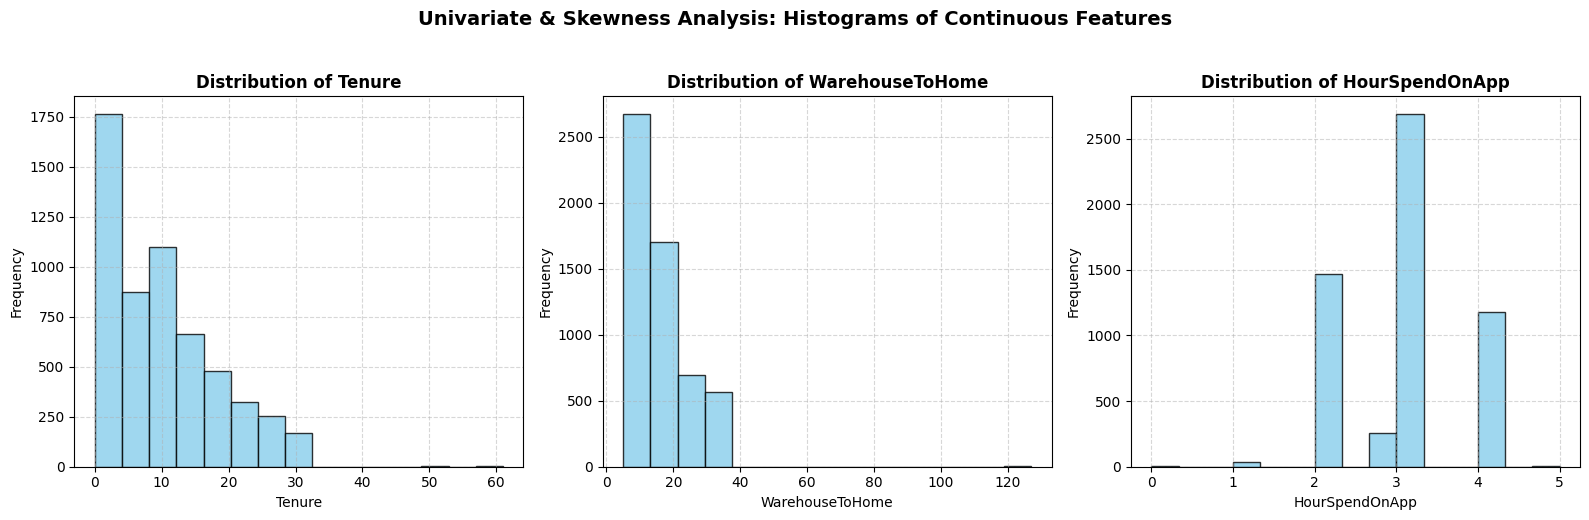

In [ ]:
# Task I - Histogram for Tenure, WarehouseToHome and HourSpendOnApp

import matplotlib.pyplot as plt

histogram_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp']

# Setting up a 1-row, 3-column canvas using subplot function
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(histogram_features):
    ax = axes[i]
    data = df_cleaned[col].dropna()

    ax.hist(data, bins=15, color='skyblue', edgecolor='black', alpha=0.8)

    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)

    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Univariate & Skewness Analysis: Histograms of Continuous Features', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

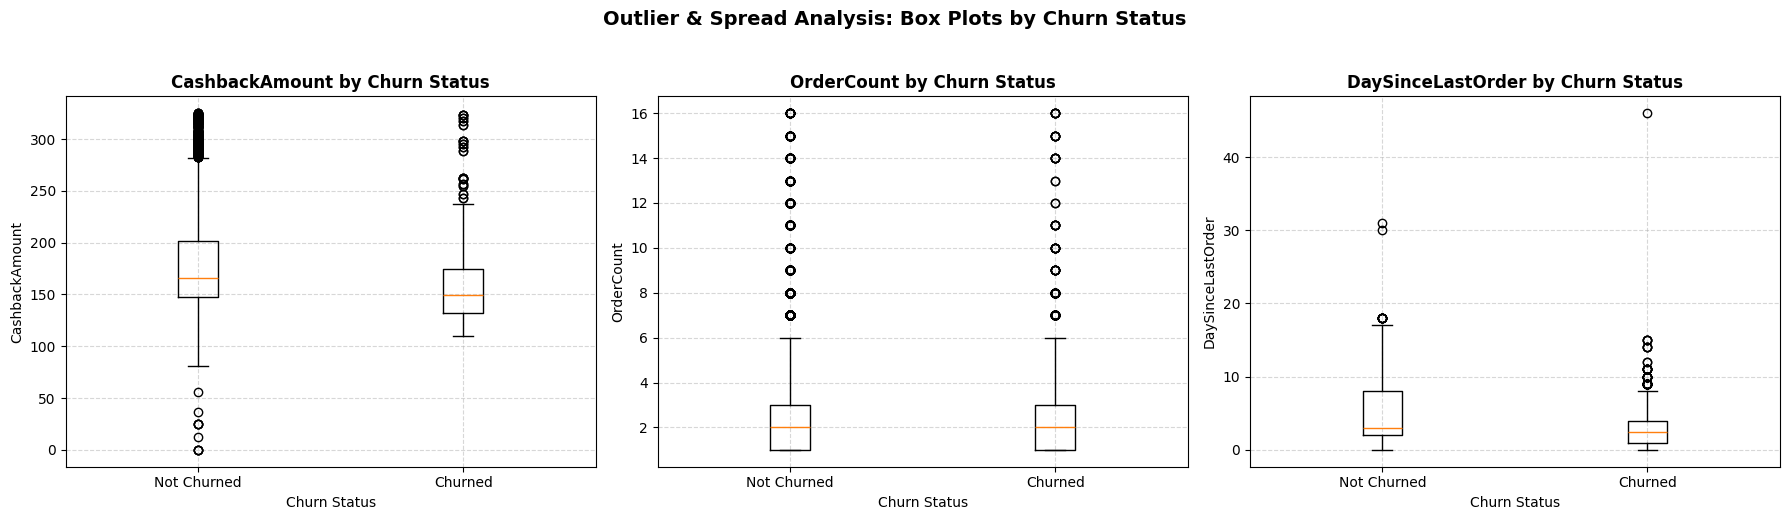

In [ ]:
# Task I - Box Plot
boxplot_features = ['CashbackAmount', 'OrderCount', 'DaySinceLastOrder']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(boxplot_features):
    ax = axes[i]
    not_churned = df_cleaned[df_cleaned["Churn"] == 0][col].dropna()
    churned = df_cleaned[df_cleaned["Churn"] == 1][col].dropna()

    ax.boxplot([not_churned, churned], tick_labels=["Not Churned", "Churned"])
    ax.set_title(f'{col} by Churn Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn Status', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Outlier & Spread Analysis: Box Plots by Churn Status', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

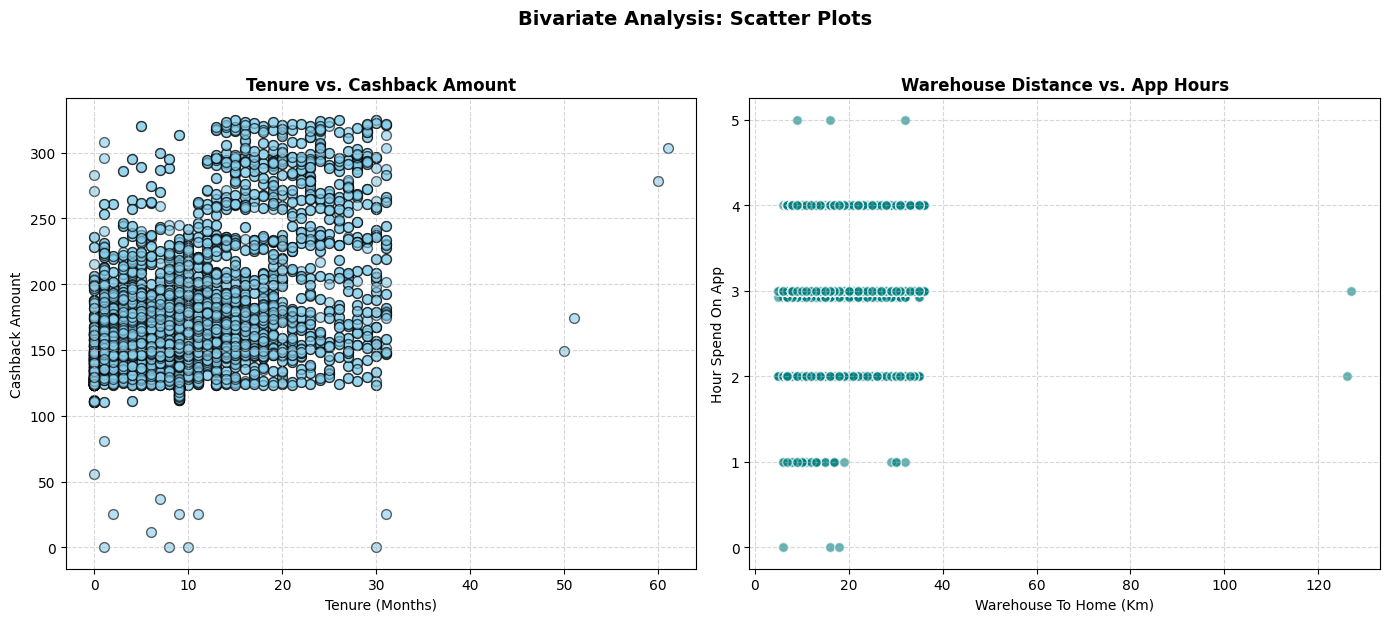

In [ ]:
# Task I - Scatter Plot of Tenure vs CashBackAmount and WarehouseToHome vs HourSpendOnApp

import matplotlib.pyplot as plt

# Setting up a 1-row, 2-column canvas using subplot function
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(df_cleaned['Tenure'], df_cleaned['CashbackAmount'],
            color='skyblue', alpha=0.6, edgecolors='black', s=50)
ax1.set_title('Tenure vs. Cashback Amount', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tenure (Months)', fontsize=10)
ax1.set_ylabel('Cashback Amount', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.scatter(df_cleaned['WarehouseToHome'], df_cleaned['HourSpendOnApp'],
            color='teal', alpha=0.6, edgecolors='w', s=50)
ax2.set_title('Warehouse Distance vs. App Hours', fontsize=12, fontweight='bold')
ax2.set_xlabel('Warehouse To Home (Km)', fontsize=10)
ax2.set_ylabel('Hour Spend On App', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Bivariate Analysis: Scatter Plots', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

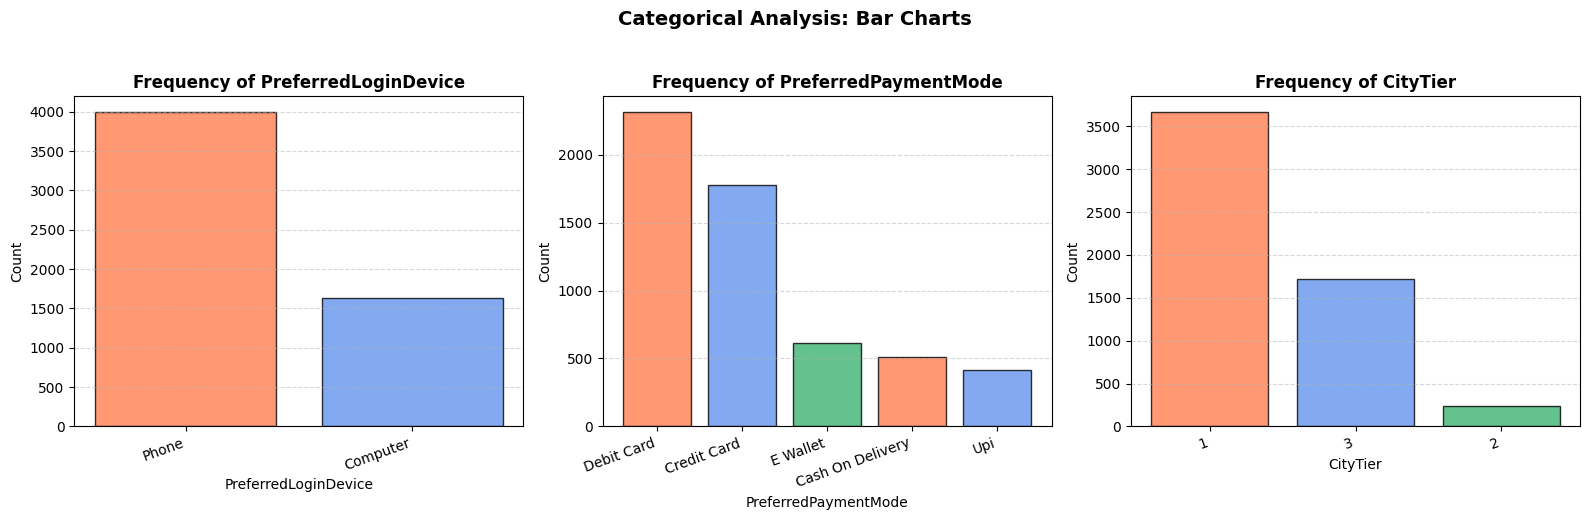

In [ ]:
# Task I - Bar chart for PreferredLoginDevice, PreferredPaymentMode and CityTier

import matplotlib.pyplot as plt

bar_features = ['PreferredLoginDevice', 'PreferredPaymentMode', 'CityTier']

# Setting up a 1-row, 3-column canvas using subplot function
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(bar_features):
    ax = axes[i]

    counts = df_cleaned[col].value_counts()
    categories = [str(cat) for cat in counts.index]
    values = counts.values

    ax.bar(categories, values, color=['coral', 'cornflowerblue', 'mediumseagreen'], edgecolor='black', alpha=0.8)

    ax.set_title(f'Frequency of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

    # Rotating x-tick labels because the text is long (especially for payment modes)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Categorical Analysis: Bar Charts', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

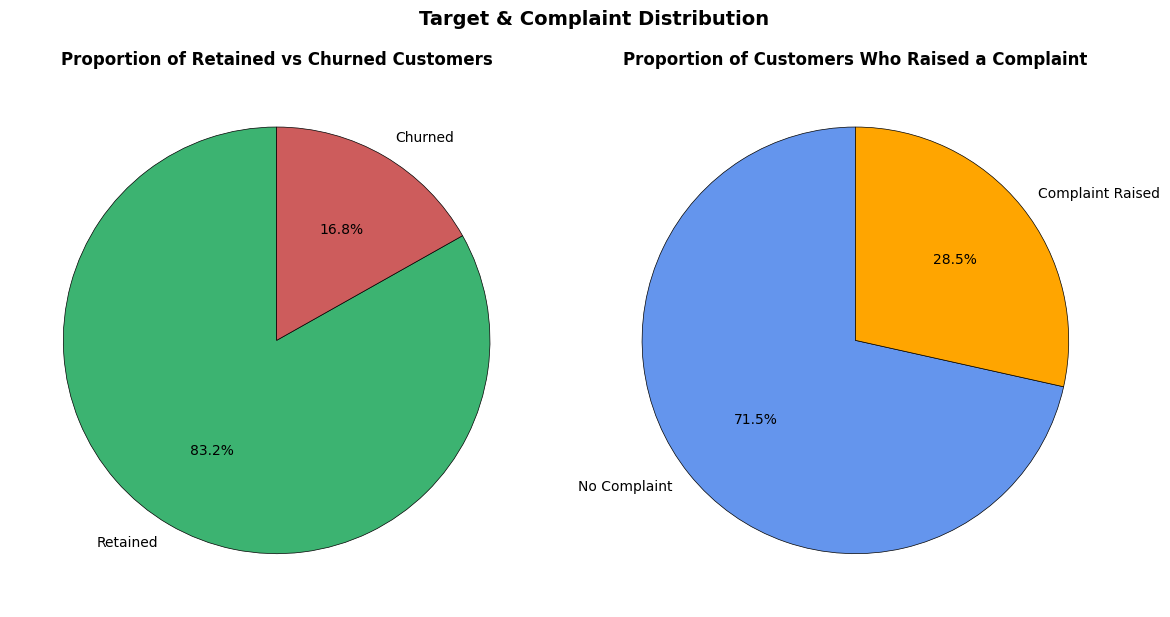

In [37]:
# Task I  - Pie Charts for Churn and Complain proportions
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Pie 1: Churn proportion ---
churn_counts = df_cleaned["Churn"].value_counts()
churn_labels = ["Retained", "Churned"]

axes[0].pie(churn_counts, labels=churn_labels, autopct='%1.1f%%',
            colors=['mediumseagreen', 'indianred'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[0].set_title('Proportion of Retained vs Churned Customers', fontsize=12, fontweight='bold')

# Pie 2: Complain proportion
complain_counts = df_cleaned["Complain"].value_counts()
complain_labels = ["No Complaint", "Complaint Raised"]

axes[1].pie(complain_counts, labels=complain_labels, autopct='%1.1f%%',
            colors=['cornflowerblue', 'orange'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('Proportion of Customers Who Raised a Complaint', fontsize=12, fontweight='bold')

plt.suptitle('Target & Complaint Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()